In [9]:
target_cols = 'K_incl'

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

input_folder=f'C:/Users/1/projects/zadachi/1 задача/{target_cols} determ'
output_file=f'{target_cols} determ.csv'
columns = ['K_Nu', 'K_E', 'K_Rho', 'K_incl', 'F', 'K_lambda_r', 'A2', 'А2_surface',  'Nu_host medium', 'E', 'Rho', 'Vp', 'Vs', 'Z']

In [11]:
def merge_txt_files_to_dataset():
    all_data = []

    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            filepath = os.path.join(input_folder, filename)
            df = pd.read_csv(filepath, sep='\s+', header=None, names=columns)

            all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df.to_csv(output_file, index=False)
    print(f"Датасет сохранен в {output_file} (строк: {len(combined_df)})")

# Пример использования

merge_txt_files_to_dataset()

Датасет сохранен в K_incl determ.csv (строк: 100100)


In [12]:
df = pd.read_csv(output_file)
df[:5]

,K_Nu,K_E,K_Rho,K_incl,F,K_lambda_r,A2,А2_surface,Nu_host medium,E,Rho,Vp,Vs,Z
0,1,1,1,0.1,0.1,10.000000,5.331341e-13,5.331372e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
1,1,1,1,0.1,0.2,5.000000,5.334827e-13,5.331472e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
2,1,1,1,0.1,0.3,3.333333,5.367524e-13,5.364047e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
3,1,1,1,0.1,0.4,2.500000,5.330409e-13,5.333102e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
4,1,1,1,0.1,0.5,2.000000,5.331411e-13,5.331653e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446


In [13]:
df['A2/A2_s'] = df['A2'] / df['А2_surface']
df

,K_Nu,K_E,K_Rho,K_incl,F,K_lambda_r,A2,А2_surface,Nu_host medium,E,Rho,Vp,Vs,Z,A2/A2_s
0,1,1,1,0.1000,0.1,10.000000,5.331341e-13,5.331372e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446,0.999994
1,1,1,1,0.1000,0.2,5.000000,5.334827e-13,5.331472e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446,1.000629
2,1,1,1,0.1000,0.3,3.333333,5.367524e-13,5.364047e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446,1.000648
3,1,1,1,0.1000,0.4,2.500000,5.330409e-13,5.333102e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446,0.999495
4,1,1,1,0.1000,0.5,2.000000,5.331411e-13,5.331653e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446,0.999955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100095,1,1,1,0.9991,9.6,0.104167,5.323251e-13,5.341700e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446,0.996546
100096,1,1,1,0.9991,9.7,0.103093,5.324428e-13,5.342459e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446,0.996625
100097,1,1,1,0.9991,9.8,0.102041,5.325628e-13,5.343239e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446,0.996704
100098,1,1,1,0.9991,9.9,0.101010,5.326846e-13,5.344037e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446,0.996783


In [14]:
pearson_corr = df[['A2', 'А2_surface', 'K_incl', 'A2/A2_s', 'F']].corr(method='pearson')
print("\nКорреляция Пирсона:")
print(pearson_corr.round(6))


Корреляция Пирсона:
                  A2  А2_surface    K_incl   A2/A2_s         F
A2          1.000000    0.789192  0.005129  0.812519 -0.521580
А2_surface  0.789192    1.000000  0.009091  0.283229 -0.269421
K_incl      0.005129    0.009091  1.000000 -0.000606  0.000000
A2/A2_s     0.812519    0.283229 -0.000606  1.000000 -0.559288
F          -0.521580   -0.269421  0.000000 -0.559288  1.000000


In [15]:
df['A2/A2_s'] = df['A2'] / df['А2_surface']
y = df[target_cols]
X = df[['A2/A2_s', 'F']]

In [16]:
scaler_X = StandardScaler()

X_scaled = scaler_X.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [18]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(2,), name='hidden_layer_1'),
    Dropout(0.2),  # Добавляем Dropout для регуляризации
    Dense(64, activation='relu', name='hidden_layer_2'),
    Dropout(0.2),
    Dense(1, name='output_layer')
])

C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Ранняя остановка для предотвращения переобучения
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Обучение модели
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0746 - mae: 0.2329 - val_loss: 0.0686 - val_mae: 0.2272
Epoch 2/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0686 - mae: 0.2261 - val_loss: 0.0683 - val_mae: 0.2267
Epoch 3/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0679 - mae: 0.2252 - val_loss: 0.0686 - val_mae: 0.2271
Epoch 4/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0677 - mae: 0.2252 - val_loss: 0.0683 - val_mae: 0.2268
Epoch 5/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0676 - mae: 0.2250 - val_loss: 0.0685 - val_mae: 0.2270
Epoch 6/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.0675 - mae: 0.2248 - val_loss: 0.0686 - val_mae: 0.2271
Epoch 7/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0675 - mae: 0.2249 - val_loss: 0.0684 - val_mae: 0.2269
Epoch 8/100
2002/2002 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0674 - mae: 0.2248 - val_loss: 0.0683 - val_mae: 0.2267
Epoch 9/100
2002/2002 ━━━

In [22]:
y_pred= np.array(model.predict(X_test)).flatten()
y_test = np.array(y_test)
y_test, y_pred

626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


(array([0.5104, 0.4546, 0.4609, ..., 0.7885, 0.2989, 0.964 ]),
 array([0.5470042, 0.5470042, 0.5470042, ..., 0.5470042, 0.5470042,
        0.5470042], dtype=float32))

In [23]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
relative_errors = np.abs((y_test - y_pred) / y_test) * 100
mean_relative_error = np.mean(relative_errors)
std_relative_error = np.std(relative_errors)

In [24]:

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ МОДЕЛИ")
print("="*50)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Absolute Per Error (MAPE): {mape:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.6f}")


РЕЗУЛЬТАТЫ МОДЕЛИ
Mean Squared Error (MSE): 0.067903
Mean Absolute Error (MAE): 0.225505
Mean Absolute Per Error (MAPE): 0.677893
Root Mean Squared Error (RMSE): 0.260583
R² Score: -0.000059


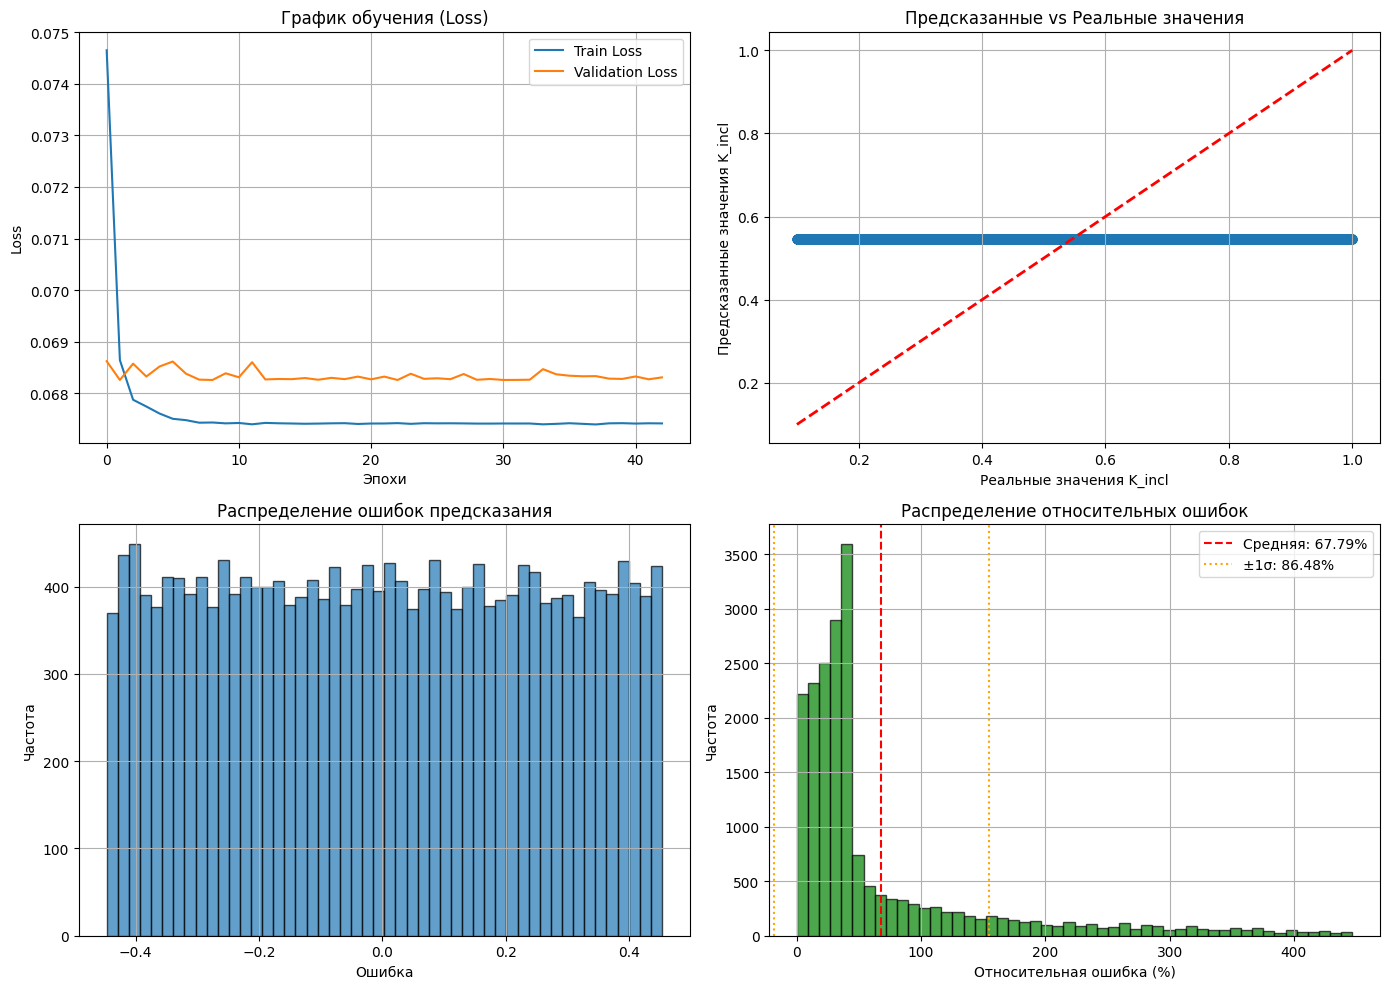


ДЕТАЛЬНАЯ СТАТИСТИКА
Минимальная относительная ошибка: 0.05%
Максимальная относительная ошибка: 447.00%
Медианная относительная ошибка: 35.96%
25-й перцентиль: 19.72%
75-й перцентиль: 69.25%

ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 10 тестовых образцов)
 Реальный K_incl  Предсказанный K_incl  Абсолютная ошибка  Относительная ошибка (%)
          0.5104              0.547004           0.036604                  7.171674
          0.4546              0.547004           0.092404                 20.326490
          0.4609              0.547004           0.086104                 18.681758
          0.3592              0.547004           0.187804                 52.284026
          0.9136              0.547004           0.366596                 40.126508
          0.1909              0.547004           0.356104                186.539666
          0.6202              0.547004           0.073196                 11.801963
          0.7480              0.547004           0.200996                 26.871093


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. График обучения
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('График обучения (Loss)')
axes[0, 0].set_xlabel('Эпохи')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Сравнение предсказанных и реальных значений
axes[0, 1].scatter(y_test, y_pred, alpha=0.5)
axes[0, 1].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('Предсказанные vs Реальные значения')
axes[0, 1].set_xlabel(f'Реальные значения {target_cols}')
axes[0, 1].set_ylabel(f'Предсказанные значения {target_cols}')
axes[0, 1].grid(True)

# 3. Распределение ошибок
errors = y_test.flatten() - y_pred.flatten()
axes[1, 0].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение ошибок предсказания')
axes[1, 0].set_xlabel('Ошибка')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].grid(True)

#
# 4. Распределение относительных ошибок
axes[1, 1].hist(relative_errors, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(mean_relative_error, color='red', linestyle='--', 
                   label=f'Средняя: {mean_relative_error:.2f}%')
axes[1, 1].axvline(mean_relative_error + std_relative_error, color='orange', 
                   linestyle=':', label=f'±1σ: {std_relative_error:.2f}%')
axes[1, 1].axvline(mean_relative_error - std_relative_error, color='orange', linestyle=':')
axes[1, 1].set_title('Распределение относительных ошибок')
axes[1, 1].set_xlabel('Относительная ошибка (%)')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n" + "="*50)
print("ДЕТАЛЬНАЯ СТАТИСТИКА")
print("="*50)
print(f"Минимальная относительная ошибка: {relative_errors.min():.2f}%")
print(f"Максимальная относительная ошибка: {relative_errors.max():.2f}%")
print(f"Медианная относительная ошибка: {np.median(relative_errors):.2f}%")
print(f"25-й перцентиль: {np.percentile(relative_errors, 25):.2f}%")
print(f"75-й перцентиль: {np.percentile(relative_errors, 75):.2f}%")


# Примеры предсказаний
print("\n" + "="*50)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 10 тестовых образцов)")
print("="*50)
examples = pd.DataFrame({
    f'Реальный {target_cols}': y_test.flatten()[:10],
    f'Предсказанный {target_cols}': y_pred.flatten()[:10],
    'Абсолютная ошибка': np.abs(y_test.flatten()[:10] - y_pred.flatten()[:10]),
    'Относительная ошибка (%)': relative_errors.flatten()[:10]
})
print(examples.to_string(index=False))

# Сохранение модели
model.save(f'{target_cols}_prediction_model.h5')
print("\nМодель сохранена")